In [1]:
import torch
import numpy as np
import math
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Variable
from sklearn.model_selection import train_test_split
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.metrics import r2_score
import random
import matplotlib as mpl
import os
import gc
import pandas as pd
import csv
from numpy import *

from torch.utils.tensorboard import SummaryWriter
from datetime import date
from generate_property import output_property

2026-05-29 19:41:20.052515: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-29 19:41:20.086256: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-29 19:41:20.734002: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
data = pd.read_excel('./All_Information.xlsx')
data = data[['Sequence', 'Aliphatic_index']]
data = data.drop(data[data['Aliphatic_index'] == 'Not Applicable'].index)
data = np.array(data)
print('Raw data shape', data.shape)

Raw data shape (4011, 2)


In [3]:
## finding the largest protein
def find_max_len(data):
    max_len = 0
    for i in range(data.shape[0]):
        str_len = list(data[i,0])
        if max_len < len(str_len):
            max_len = len(str_len)
    print('Max len is', max_len)
    return max_len

max_len = find_max_len(data)

Max len is 97


In [4]:
# different amino acids
amino_acid = ['A', 'V', 'F', 'I', 'L','D','E','K','S','T','Y','C','N','Q', 'P','M', 'R', 'H', 'W', 'G']
print('Number of unique amino acids are', np.shape(np.unique(amino_acid))[0])

def onehotseq(sequence):
  aa_seq = ''
  seq_len = len(sequence)
  seq_en = np.zeros(( seq_len, np.shape(amino_acid)[0]))
  act_len = 0
  for i in range(seq_len):
    if sequence[i] in amino_acid:
      pos = amino_acid.index(sequence[i])
      seq_en[act_len,pos] = 1
      act_len += 1  
      aa_seq += sequence[i]    
    elif (sequence[i] not in amino_acid) and (sequence[i] != " ") and (sequence[i] != '\ufeff'):
      pos = amino_acid.index('X')
      seq_en[act_len,pos] = 1
      act_len += 1 
      aa_seq += sequence[i]
  return seq_en[0:act_len, :], aa_seq

Number of unique amino acids are 20


In [5]:
ohe = np.zeros((data.shape[0], max_len, len(amino_acid)))
seq_string = np.zeros((data.shape[0],), dtype=object)
seq_lengths = np.zeros((data.shape[0],))
tm = np.zeros((data.shape[0], 1))

for i in range(ohe.shape[0]):
    seq_en, aa_seq = onehotseq(list(data[i,0]))
    seq_string[i,] = aa_seq
    ohe[i,0:seq_en.shape[0],:] =  seq_en
    seq_lengths[i,] = seq_en.shape[0]
    tm[i,0] = data[i,1]

output_y = tm
seq_length = seq_lengths

print(f'Total sequences: {len(ohe)}')
print(f'Example sequence: {seq_string[10]}')

# Calculate Aliphatic Index property
toy_prop = output_property(seq_string)
output_y = toy_prop

# Filter sequences with length > 20
idx_20 = (seq_length > 20)
seq_length = seq_length[idx_20]
seq_string = seq_string[idx_20]
output_y = output_y[idx_20]
ohe = ohe[idx_20]

print(f'After length filtering (>20): {len(ohe)} sequences')

Total sequences: 4011
Example sequence: GLFDIVKKVVGAFGSL
After length filtering (>20): 1179 sequences


In [6]:
# Filter to keep only sequences with aliphatic index <= 75
cutoff = 75
filter_idx = output_y <= cutoff

print(f'Original data size: {len(output_y)}')
print(f'Cutoff: {cutoff}')
print(f'Samples with y <= {cutoff}: {np.sum(filter_idx)}')

# Apply filter
ohe = ohe[filter_idx]
seq_length = seq_length[filter_idx]
seq_string = seq_string[filter_idx]
output_y = output_y[filter_idx]

print(f'Filtered data size: {len(output_y)}')
print(f'Y range after filtering: [{output_y.min():.4f}, {output_y.max():.4f}]')

# Train/test/valid split on filtered data
all_ex = np.arange(ohe.shape[0])
X, x_test, _, _ = train_test_split(all_ex, all_ex, test_size=0.127, random_state=50)
x_train, x_valid, _, _ = train_test_split(X, X, test_size=0.145, random_state=50)
_, x_train, _, _ = train_test_split(x_train, x_train, test_size=0.967, random_state=1000)

print('Train', x_train.shape)
print('Test', x_test.shape)
print('Valid', x_valid.shape)

print(ohe[x_train].shape, seq_length[x_train].shape, output_y[x_train].shape)

Original data size: 1179
Cutoff: 75
Samples with y <= 75: 579
Filtered data size: 579
Y range after filtering: [0.0000, 75.0000]
Train (417,)
Test (74,)
Valid (74,)
(417, 97, 20) (417,) (417,)


In [7]:
np.save('./x_train', ohe[x_train])
np.save('./len_train', seq_length[x_train])
np.save('./y_train', output_y[x_train])
np.save('./seq_train', seq_string[x_train])

np.save('./x_valid', ohe[x_valid])
np.save('./len_valid', seq_length[x_valid])
np.save('./y_valid', output_y[x_valid])
np.save('./seq_valid', seq_string[x_valid])

np.save('./x_test', ohe[x_test])
np.save('./len_test', seq_length[x_test])
np.save('./y_test', output_y[x_test])
np.save('./seq_test', seq_string[x_test])

Text(0, 0.5, 'Count')

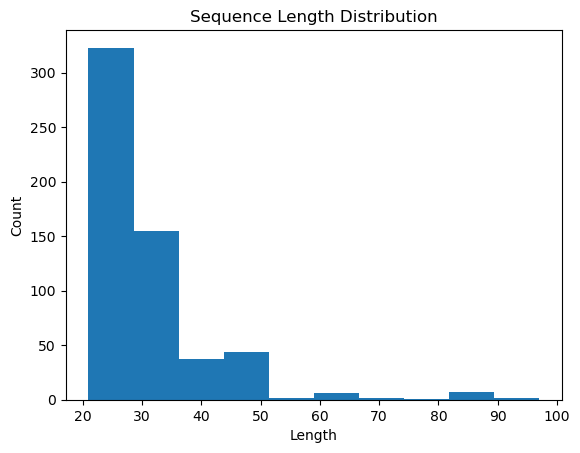

In [8]:
plt.hist(seq_length)
plt.title('Sequence Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

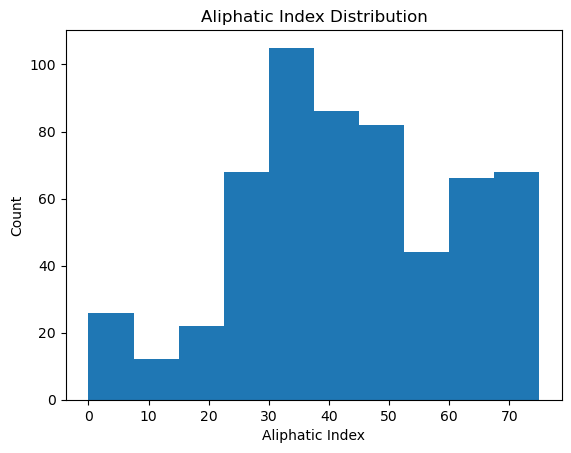

In [9]:
plt.hist(output_y)
plt.title('Aliphatic Index Distribution')
plt.xlabel('Aliphatic Index')
plt.ylabel('Count')